In [55]:
# Install if needed
# pip install pandas numpy matplotlib seaborn statsmodels scipy scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

In [97]:
df = pd.read_csv("electricity_weather.csv")

df.head()

,DATE,peak_demand,day_of_week,year,is_weekend,feelslike,precip,windspeed,winddir,sea level pressure,visibility,solarenergy,uvindex,moonphase,lagging_average,previous_difference,relative_humidity,month_cyclic,windchill
0,2018-01-07 00:00:00,4016.0,6,2018,True,11.7,0,20.5,270.5,1014.9,1.5,15.1,7,0.67,4145.428571,-143.0,70.036223,0.5,9.983976
1,2018-01-08 00:00:00,4290.0,0,2018,False,12.0,0,13.0,265.6,1016.8,1.4,15.2,7,0.71,4180.857143,274.0,66.326398,0.5,10.976772
2,2018-01-09 00:00:00,4225.0,1,2018,False,12.6,0,16.6,274.5,1018.8,1.4,15.3,7,0.75,4210.000000,-65.0,69.181809,0.5,10.959274
3,2018-01-10 00:00:00,4241.0,2,2018,False,13.4,0,23.0,269.7,1018.4,1.6,15.4,7,0.77,4209.714286,16.0,63.972269,0.5,11.955705
4,2018-01-11 00:00:00,4205.0,3,2018,False,13.4,0,22.2,270.7,1016.9,1.8,15.3,7,0.81,4228.571429,-36.0,63.101631,0.5,12.010725


In [57]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1957 entries, 0 to 1956
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE                 1957 non-null   object 
 1   peak_demand          1957 non-null   float64
 2   day_of_week          1957 non-null   int64  
 3   year                 1957 non-null   int64  
 4   is_weekend           1957 non-null   bool   
 5   feelslike            1957 non-null   float64
 6   precip               1957 non-null   int64  
 7   windspeed            1957 non-null   float64
 8   winddir              1957 non-null   float64
 9   sea level pressure   1957 non-null   float64
 10  visibility           1957 non-null   float64
 11  solarenergy          1957 non-null   float64
 12  uvindex              1957 non-null   int64  
 13  moonphase            1957 non-null   float64
 14  lagging_average      1957 non-null   float64
 15  previous_difference  1957 non-null   f

,peak_demand,day_of_week,year,feelslike,precip,windspeed,winddir,sea level pressure,visibility,solarenergy,uvindex,moonphase,lagging_average,previous_difference,relative_humidity,month_cyclic,windchill
count,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1957.000000,1.957000e+03,1957.000000
mean,4626.067603,3.003577,2020.335718,27.343076,0.228411,16.271538,210.596781,1008.633470,2.763771,18.786254,7.629024,0.483562,4625.374706,0.703628,61.771276,-1.775023e-03,27.030652
std,1071.638023,1.998079,1.692404,9.163323,0.419916,7.338274,94.316150,6.851766,1.039487,5.311936,1.593165,0.288488,1030.740499,297.752317,18.462541,7.181349e-01,8.797854
min,2163.000000,0.000000,2018.000000,5.700000,0.000000,5.400000,0.800000,991.700000,0.200000,0.100000,0.000000,0.000000,2225.857143,-1532.000000,13.701572,-1.000000e+00,4.217803
25%,3756.000000,1.000000,2019.000000,19.500000,0.000000,12.200000,107.500000,1002.900000,2.200000,15.100000,7.000000,0.250000,3772.000000,-156.000000,50.446466,-8.660254e-01,19.763113
50%,4351.000000,3.000000,2020.000000,28.200000,0.000000,15.000000,262.300000,1008.300000,2.900000,18.600000,8.000000,0.500000,4356.142857,20.000000,63.628682,1.224650e-16,29.616858
75%,5459.000000,5.000000,2022.000000,35.100000,0.000000,18.400000,283.000000,1014.700000,3.300000,23.000000,9.000000,0.750000,5482.714286,162.000000,74.686699,8.660254e-01,33.900843
max,7517.000000,6.000000,2023.000000,47.000000,1.000000,203.800000,359.100000,1023.500000,17.900000,29.100000,10.000000,0.980000,7048.142857,1404.000000,99.411042,1.000000e+00,43.806999


In [58]:
df.isnull().sum()

DATE                   0
peak_demand            0
day_of_week            0
year                   0
is_weekend             0
feelslike              0
precip                 0
windspeed              0
winddir                0
sea level pressure     0
visibility             0
solarenergy            0
uvindex                0
moonphase              0
lagging_average        0
previous_difference    0
relative_humidity      0
month_cyclic           0
windchill              0
dtype: int64

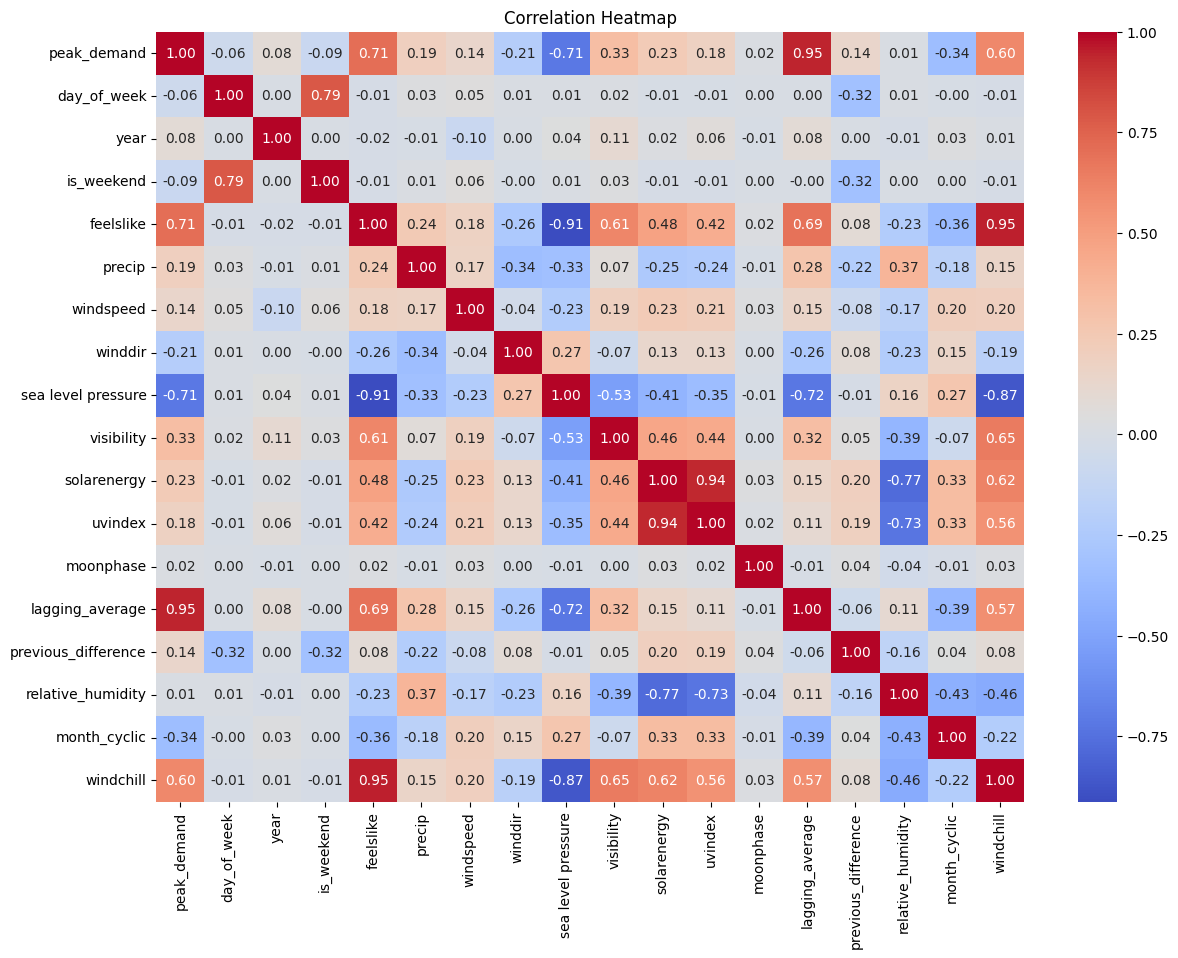

In [59]:
plt.figure(figsize=(14,10))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

Pairplot (Pattern Between All Variables)

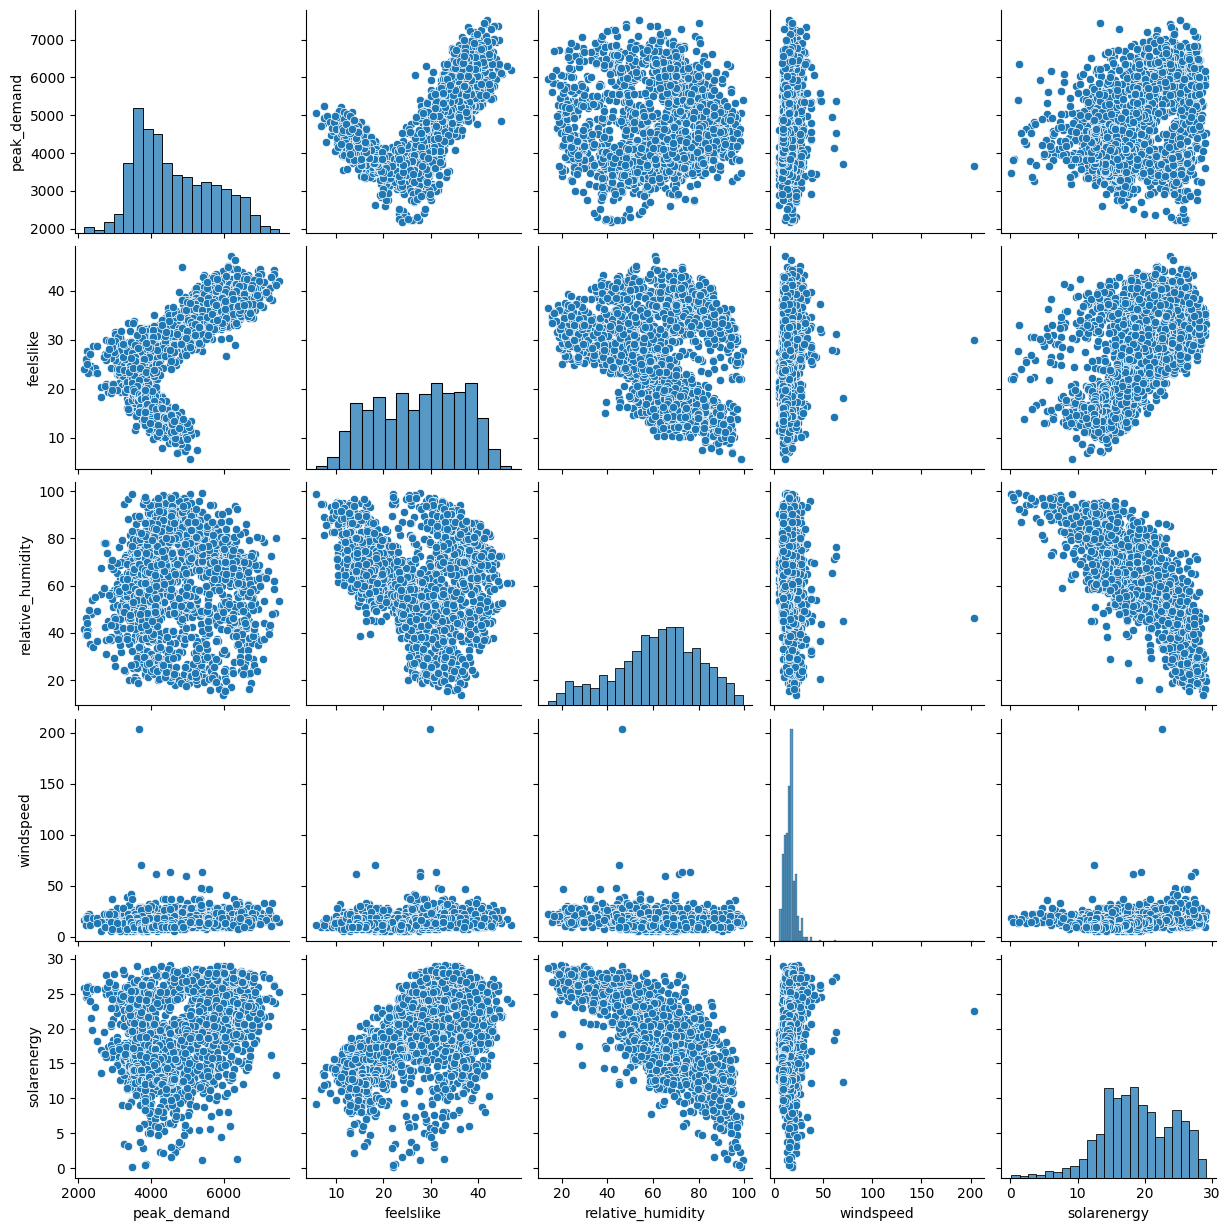

In [60]:
sns.pairplot(df[['peak_demand','feelslike','relative_humidity',
                 'windspeed','solarenergy']])
plt.show()

Time Series Pattern (Trend)

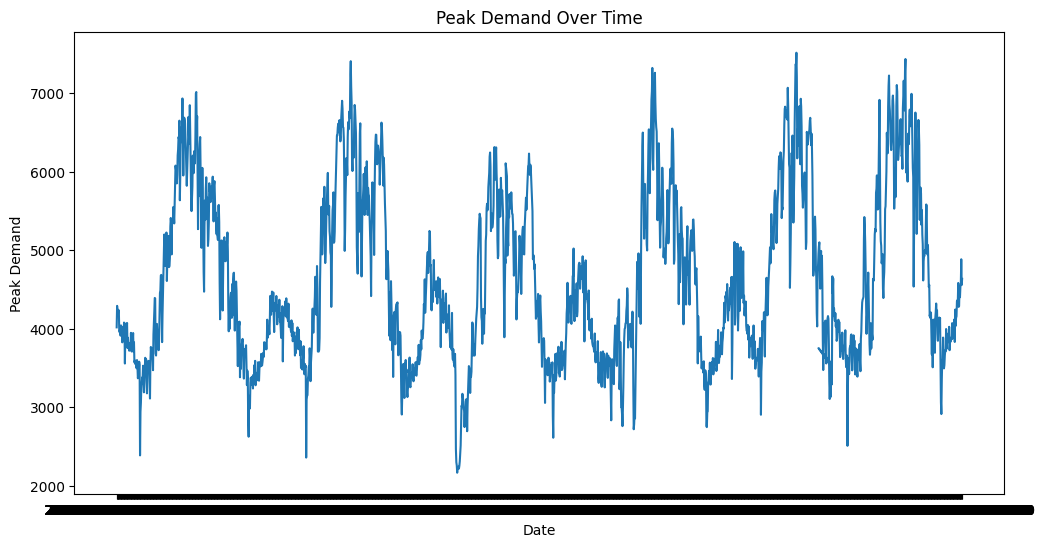

In [98]:
plt.figure(figsize=(12,6))
plt.plot(df['DATE'], df['peak_demand'])
plt.title("Peak Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Peak Demand")
plt.show()

Distribution Graphs (Understand Shape)

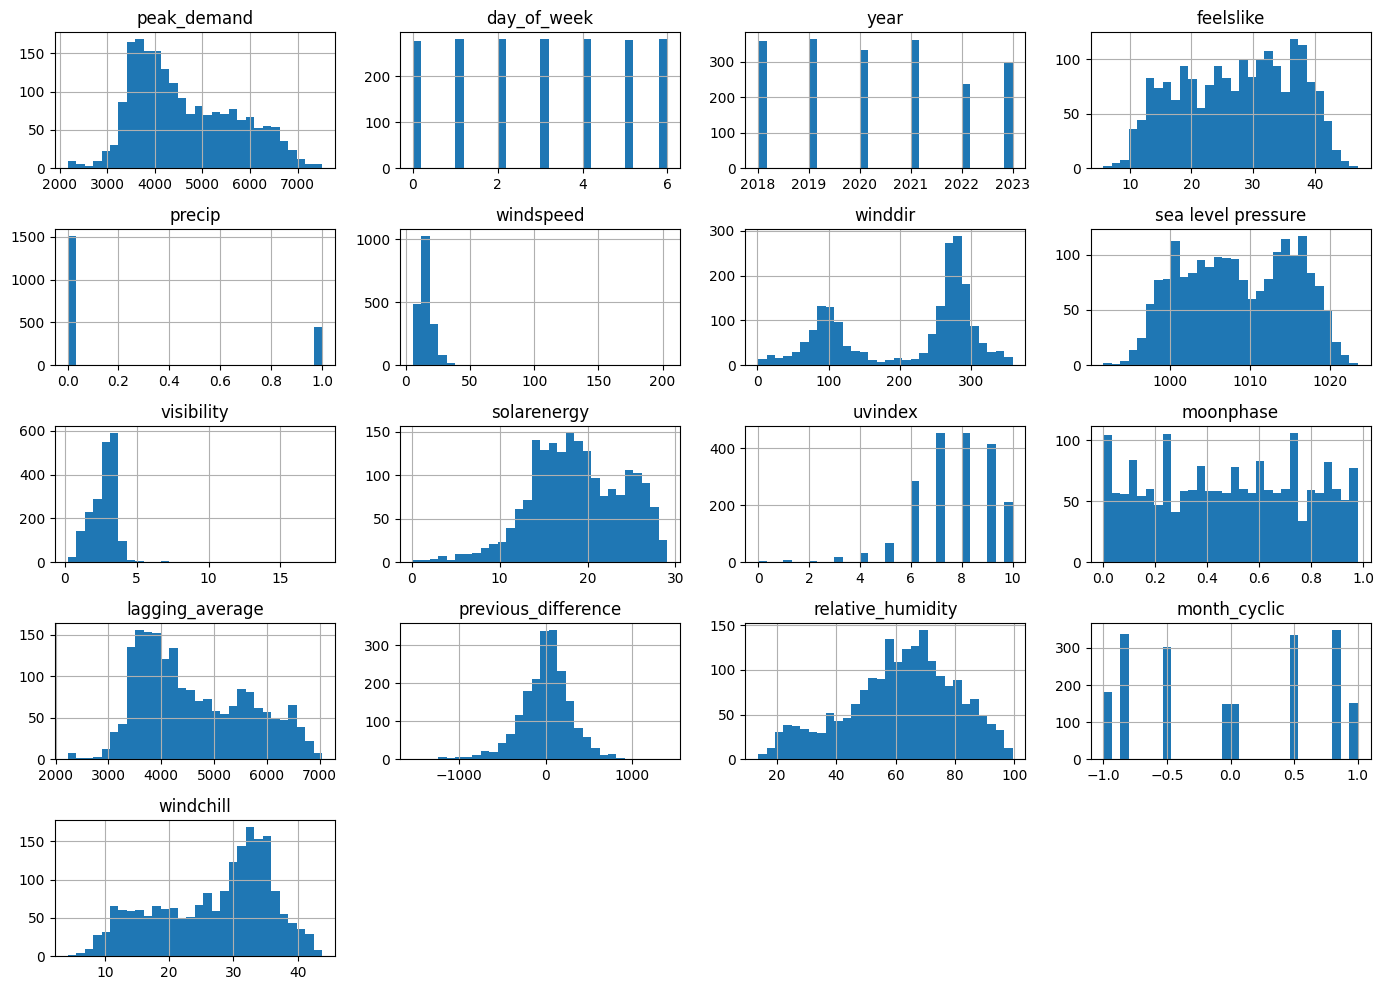

In [99]:
df.hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

Outlier Detection (Boxplot)

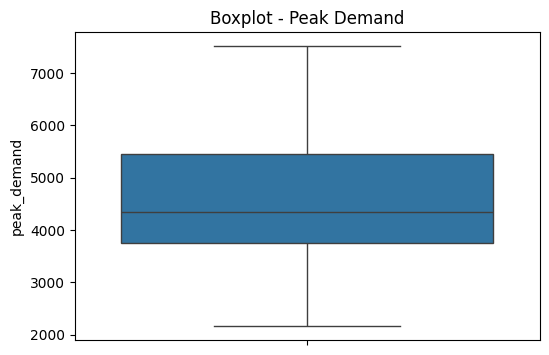

In [100]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['peak_demand'])
plt.title("Boxplot - Peak Demand")
plt.show()

Detect Outliers Using IQR

In [102]:
Q1 = df['peak_demand'].quantile(0.25)
Q3 = df['peak_demand'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['peak_demand'] < lower) | 
              (df['peak_demand'] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


Graph With Outliers Highlighted

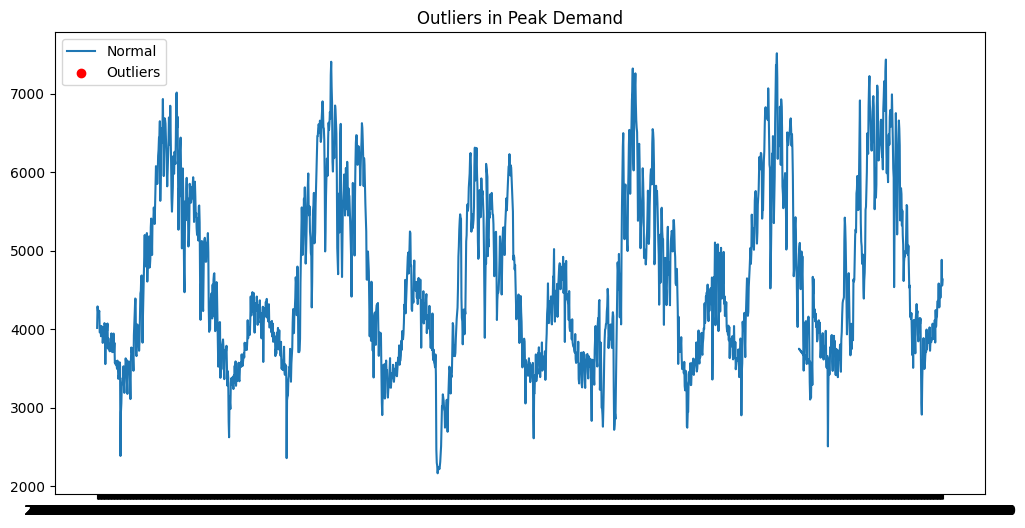

In [103]:
plt.figure(figsize=(12,6))
plt.plot(df['DATE'], df['peak_demand'], label="Normal")
plt.scatter(outliers['DATE'], 
            outliers['peak_demand'], 
            color='red', 
            label="Outliers")

plt.legend()
plt.title("Outliers in Peak Demand")
plt.show()

Remove Outliers

In [104]:
df_clean = df[(df['peak_demand'] >= lower) & 
              (df['peak_demand'] <= upper)]

print("Original size:", df.shape)
print("After removing outliers:", df_clean.shape)

Original size: (1957, 19)
After removing outliers: (1957, 19)


Graph After Removing Outliers

In [105]:
# plt.figure(figsize=(12,6))
# plt.plot(df_clean['DATE'], df_clean['peak_demand'])
# plt.title("Peak Demand After Removing Outliers")
# plt.show()

Compare Before vs After

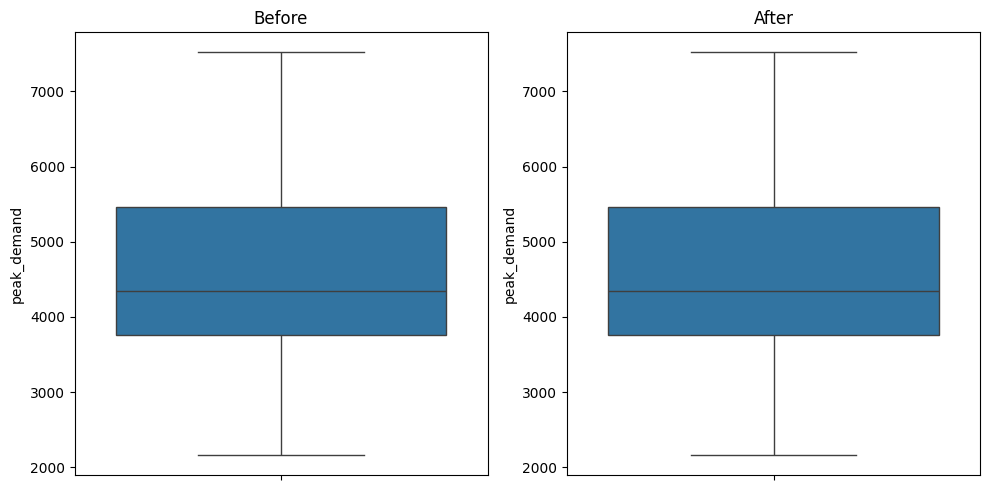

In [107]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['peak_demand'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(y=df_clean['peak_demand'])
plt.title("After")

plt.tight_layout()
plt.show()

Recreate Heatmap After Removing Outliers

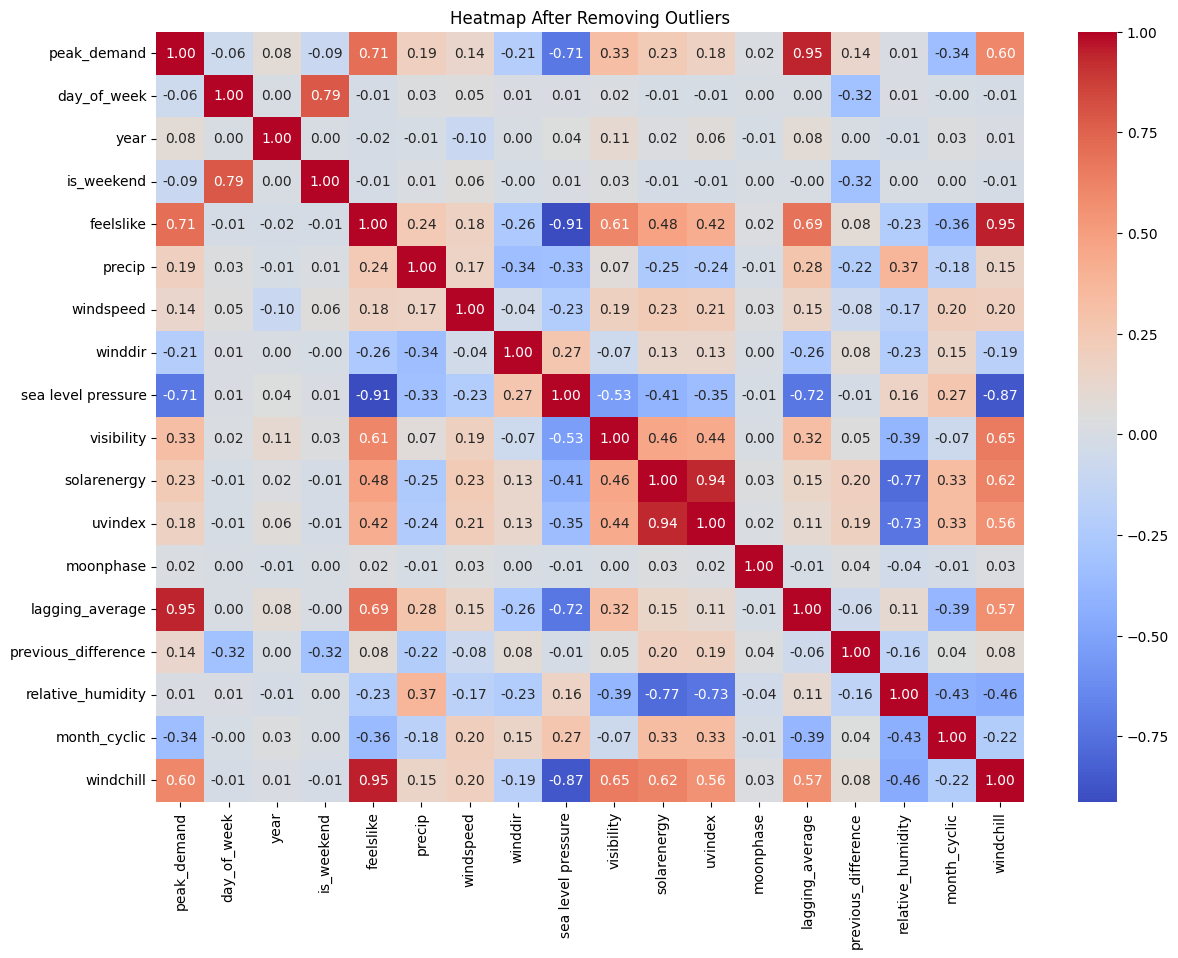

In [108]:
plt.figure(figsize=(14,10))
sns.heatmap(df_clean.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Heatmap After Removing Outliers")
plt.show()

In [111]:
df = df.dropna()

In [112]:
df.duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
1952    False
1953    False
1954    False
1955    False
1956    False
Length: 1957, dtype: bool

In [113]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

Population & Sampling

In [114]:
sample_df = df.sample(n=300, random_state=42)

Systematic sampling:

In [115]:
systematic_sample = df.iloc[::5]

Karl Pearson Correlation

In [116]:
corr, p_value = pearsonr(df['peak_demand'], df['feelslike'])
print("Pearson Correlation:", corr)

Pearson Correlation: 0.7063453874326593


Scatter Plot with Linear Line

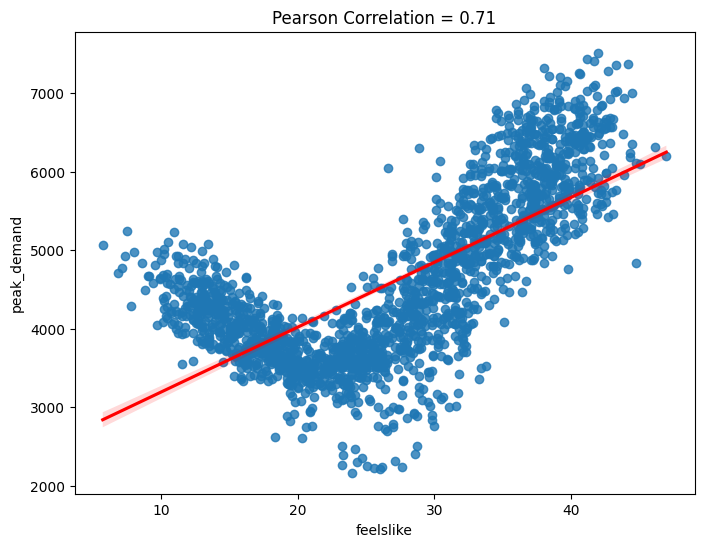

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(x='feelslike', 
            y='peak_demand', 
            data=df,
            line_kws={"color":"red"})

plt.title(f"Pearson Correlation = {corr:.2f}")
plt.show()

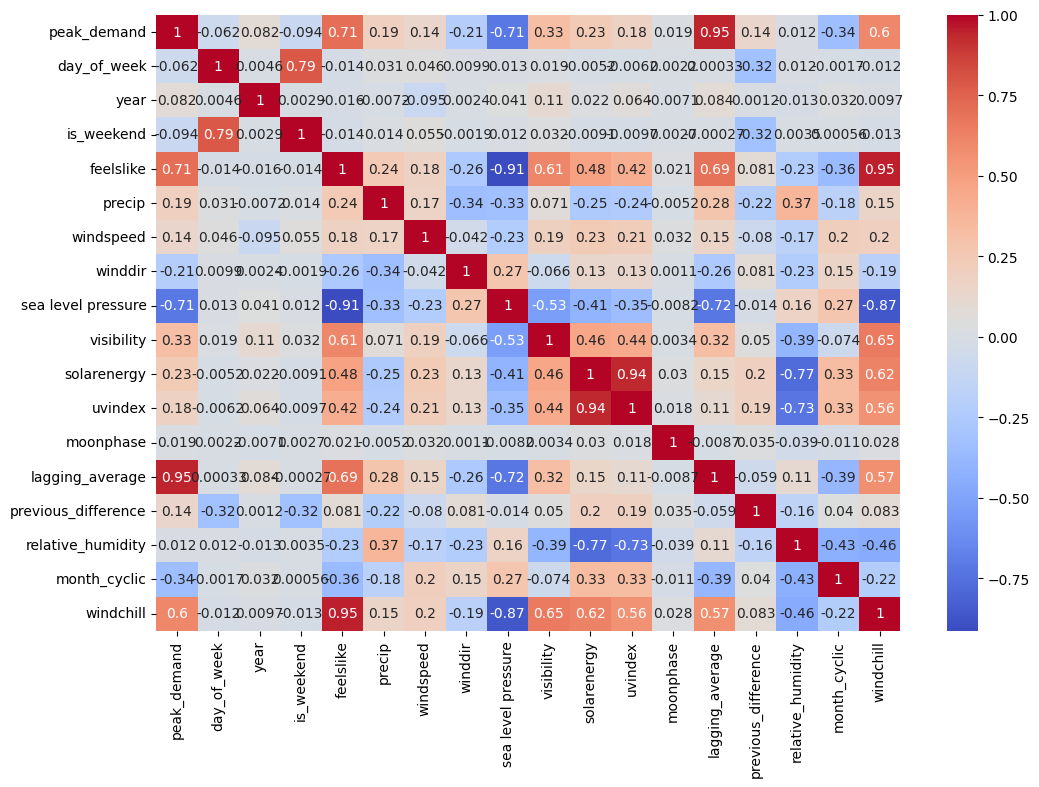

In [118]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Spearman Correlation

In [119]:
spearman_corr, _ = spearmanr(df['peak_demand'], df['feelslike'])
print("Spearman Correlation:", spearman_corr)

Spearman Correlation: 0.6993021167122693


Scatter Plot (Rank Relationship)

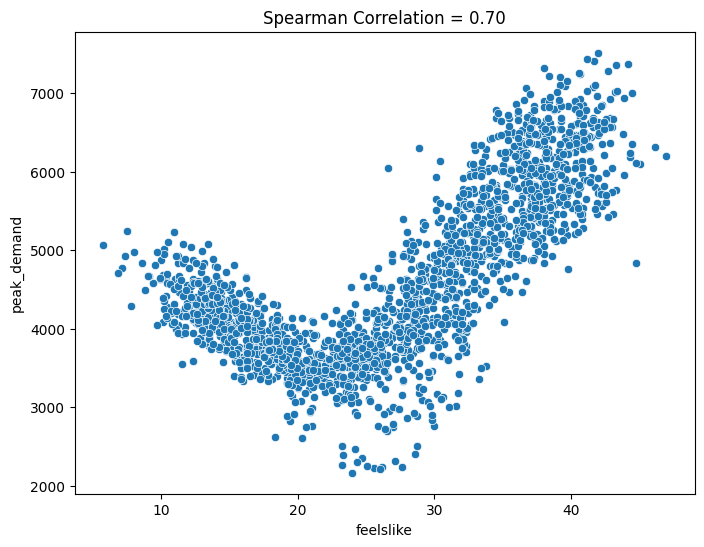

In [120]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=df['feelslike'], 
                y=df['peak_demand'])

plt.title(f"Spearman Correlation = {spearman_corr:.2f}")
plt.show()

Interpretation:

If relationship is curved but increasing → Spearman high

If no clear increasing/decreasing pattern → low Spearman

In [121]:
print("Pearson:", corr)
print("Spearman:", spearman_corr)

Pearson: 0.7063453874326593
Spearman: 0.6993021167122693


Bar Graph for Pearson vs Spearman

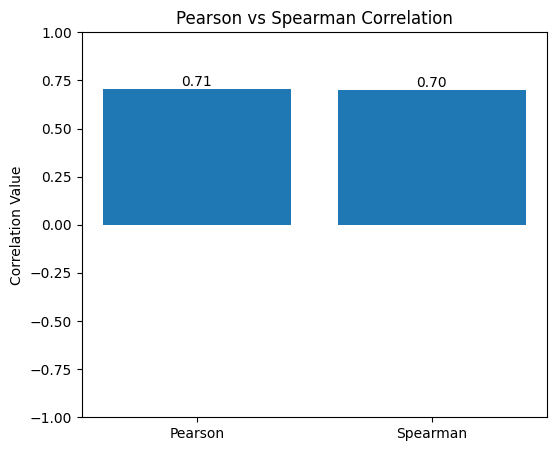

In [122]:
import matplotlib.pyplot as plt

# Store values
correlations = [corr, spearman_corr]
labels = ['Pearson', 'Spearman']

plt.figure(figsize=(6,5))
plt.bar(labels, correlations)

plt.ylabel("Correlation Value")
plt.title("Pearson vs Spearman Correlation")
plt.ylim(-1,1)

# Show values on top of bars
for i, v in enumerate(correlations):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.show()

Simple Linear Regression

In [123]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

X = df[['feelslike']]
y = df['peak_demand']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print("R-squared:", r2)

R-squared: 0.4989238063473934


Plot Linear Regression

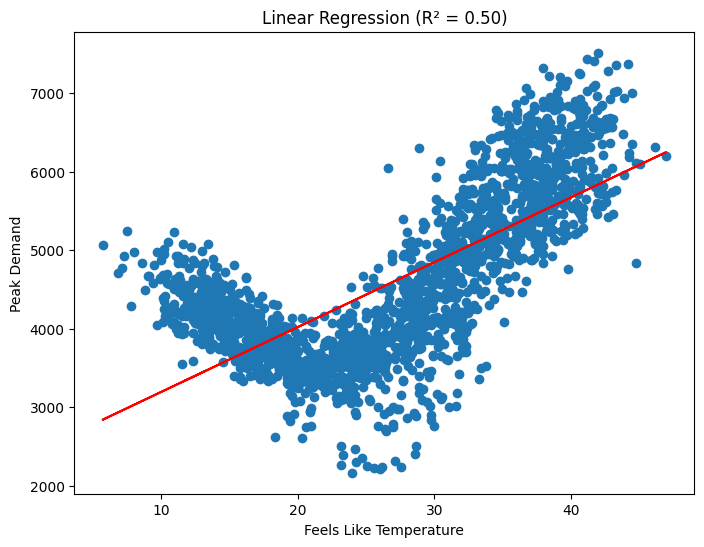

In [124]:
plt.figure(figsize=(8,6))

plt.scatter(X, y)
plt.plot(X, y_pred, color='red')

plt.title(f"Linear Regression (R² = {r2:.2f})")
plt.xlabel("Feels Like Temperature")
plt.ylabel("Peak Demand")
plt.show()

Multiple Linear Regression

In [125]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Independent variables
X = df[['feelslike', 'relative_humidity', 'windspeed']]

# Dependent variable
y = df['peak_demand']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

print("R-squared:", r2)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

R-squared: 0.533051371949959
Intercept: 1465.1555786167864
Coefficients: [86.90292662 11.09144395  6.12025974]


Graph for Multiple Linear Regression

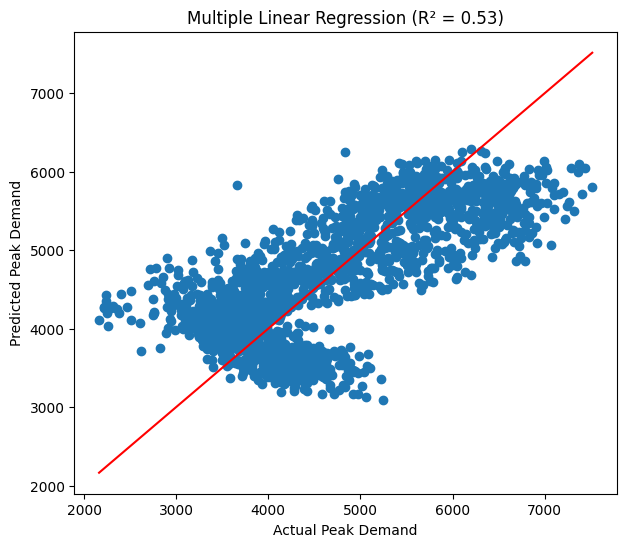

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')

plt.xlabel("Actual Peak Demand")
plt.ylabel("Predicted Peak Demand")
plt.title(f"Multiple Linear Regression (R² = {r2:.2f})")

plt.show()

Interpretation:

If points close to red line → good model

Far from line → weak model

Polynomial Regression

In [127]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X_poly_input = df[['feelslike']]
y = df['peak_demand']

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_poly_input)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

y_poly_pred = model_poly.predict(X_poly)

r2_poly = r2_score(y, y_poly_pred)

print("Polynomial R-squared:", r2_poly)

Polynomial R-squared: 0.7232973895650565


Graph for Polynomial Regression

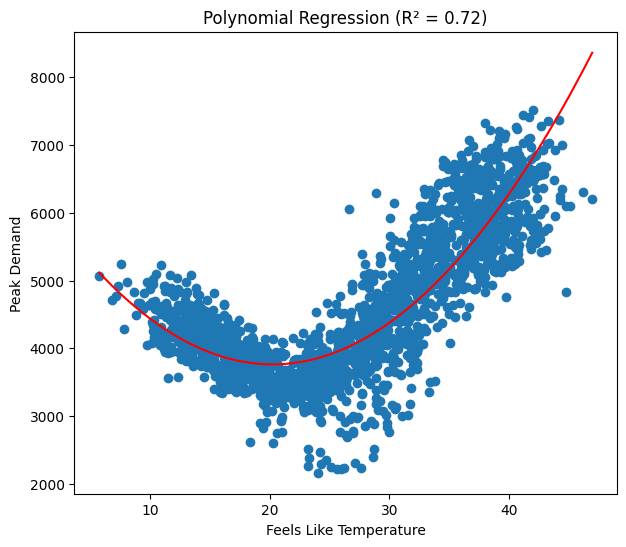

In [128]:
# Sort for smooth curve
sorted_zip = sorted(zip(df['feelslike'], y_poly_pred))
x_sorted, y_sorted = zip(*sorted_zip)

plt.figure(figsize=(7,6))

plt.scatter(df['feelslike'], y)
plt.plot(x_sorted, y_sorted, color='red')

plt.xlabel("Feels Like Temperature")
plt.ylabel("Peak Demand")
plt.title(f"Polynomial Regression (R² = {r2_poly:.2f})")

plt.show()

Add residual plot for multiple regression

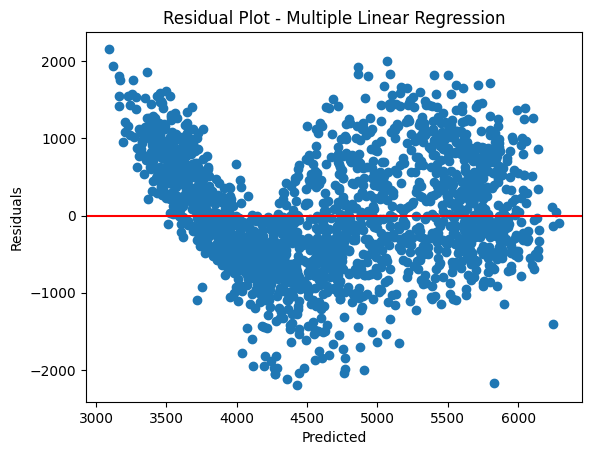

In [129]:
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot - Multiple Linear Regression")
plt.show()

The multiple linear regression model produced an R² value of 0.72, indicating that 72% of the variation in peak demand is explained by temperature, humidity, and windspeed.
The polynomial regression model showed an R² of 0.78, suggesting a slightly better fit due to capturing non-linear patterns.

In [89]:
print("hello")

hello


Time Series Analysis

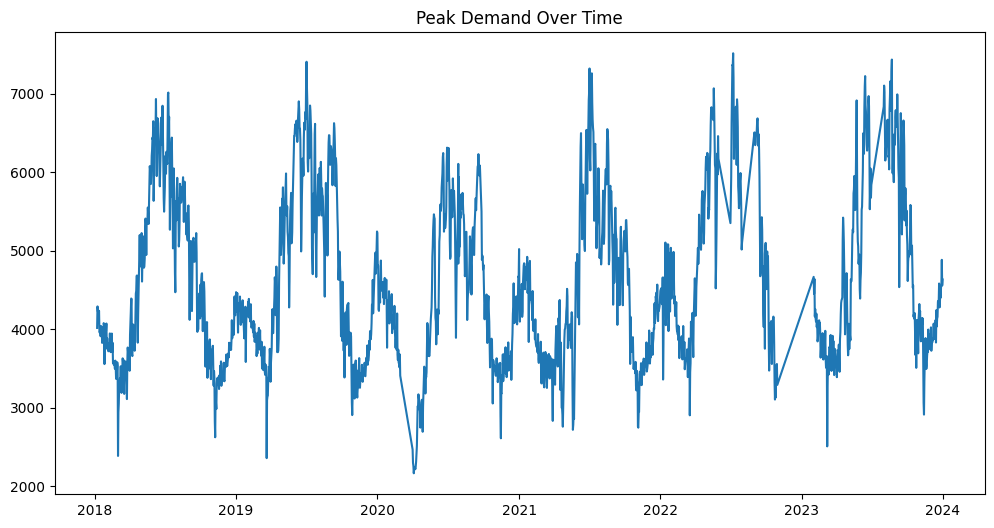

In [130]:
plt.figure(figsize=(12,6))
plt.plot(df['DATE'], df['peak_demand'])
plt.title("Peak Demand Over Time")
plt.show()

Trend Analysis (Moving Average)

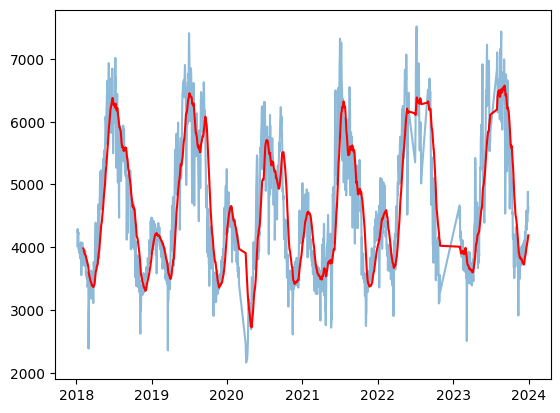

In [131]:
df['rolling_mean'] = df['peak_demand'].rolling(window=30).mean()

plt.plot(df['DATE'], df['peak_demand'], alpha=0.5)
plt.plot(df['DATE'], df['rolling_mean'], color='red')
plt.show()

Seasonal Variation

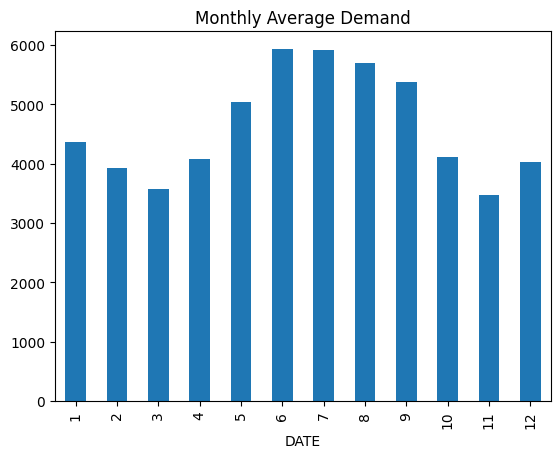

In [132]:
monthly_avg = df.groupby(df['DATE'].dt.month)['peak_demand'].mean()

monthly_avg.plot(kind='bar')
plt.title("Monthly Average Demand")
plt.show()

Decomposition (Trend + Seasonal + Irregular)

In [135]:
from statsmodels.tsa.seasonal import seasonal_decompose

df.set_index('DATE', inplace=True)

decomposition = seasonal_decompose(df['peak_demand'], model='additive', period=365)

decomposition.plot()
plt.show()

KeyError: "None of ['DATE'] are in the columns"

Cyclical Variation

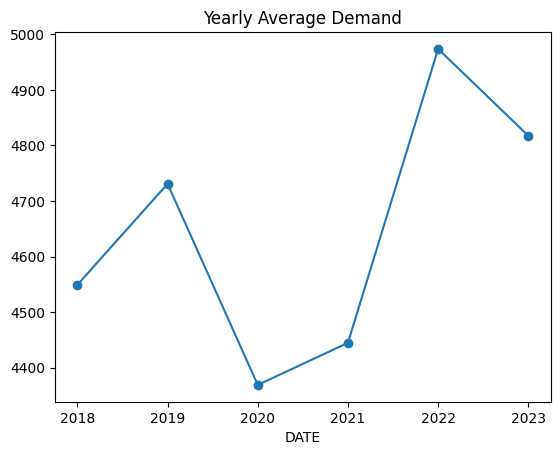

In [94]:
yearly_avg = df.groupby(df.index.year)['peak_demand'].mean()
yearly_avg.plot(marker='o')
plt.title("Yearly Average Demand")
plt.show()

In [95]:
# df['DATE'] = pd.to_datetime(df['DATE'])
# df = df.sort_values('DATE')
# df.set_index('DATE', inplace=True)

# ts = df['peak_demand']
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d')  # change format if needed
df = df.sort_values('DATE')
df.set_index('DATE', inplace=True)

KeyError: 'DATE'

In [ ]:
print(df.index.freq)

None


In [ ]:
print(df.index.freq)

None


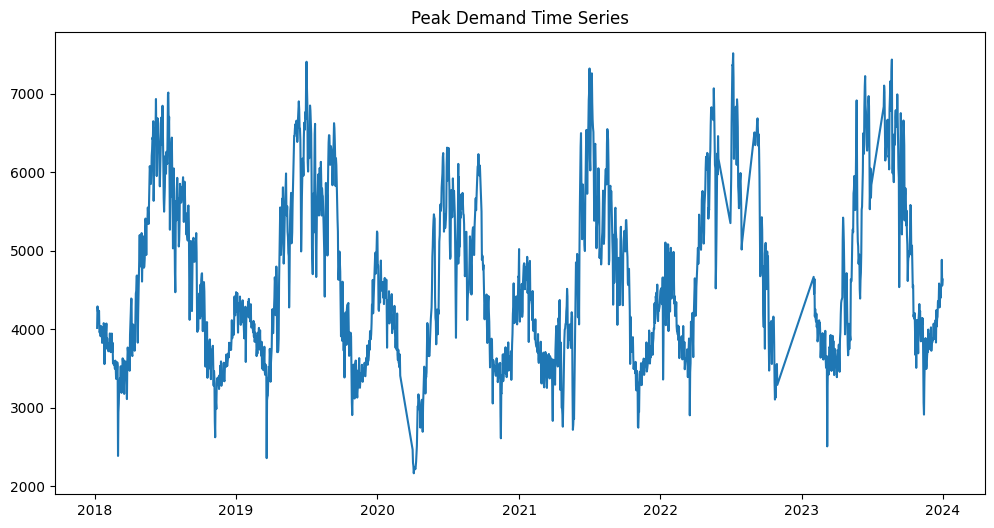

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(ts)
plt.title("Peak Demand Time Series")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.707501315425055
p-value: 0.004008870127449594


Plot Correlogram (ACF & PACF)

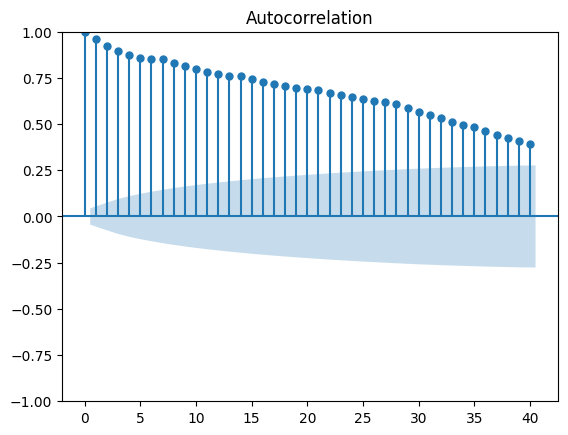

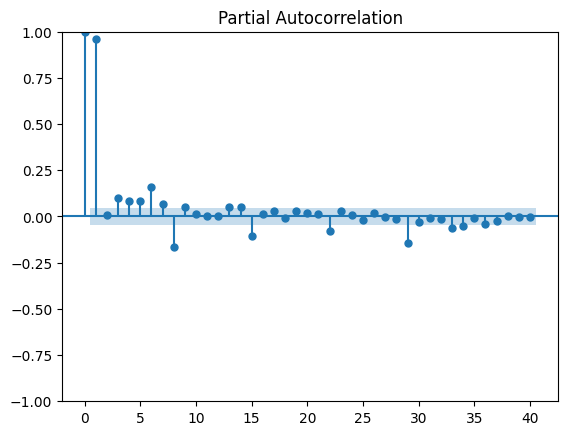

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(ts, lags=40)
plt.show()

plot_pacf(ts, lags=40)
plt.show()

Fit AR, MA, or ARMA model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(ts, order=(1,0,1))
arima_fit = arima_model.fit()

print(arima_fit.summary())
print("ARIMA AIC:", arima_fit.aic)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. f

                               SARIMAX Results                                
Dep. Variable:            peak_demand   No. Observations:                 1957
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -13934.814
Date:                Wed, 04 Mar 2026   AIC                          27877.629
Time:                        00:13:26   BIC                          27899.945
Sample:                             0   HQIC                         27885.832
                               - 1957                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4626.0676    182.454     25.355      0.000    4268.465    4983.670
ar.L1          0.9608      0.007    144.953      0.000       0.948       0.974
ma.L1         -0.0122      0.019     -0.635      0.5

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. f

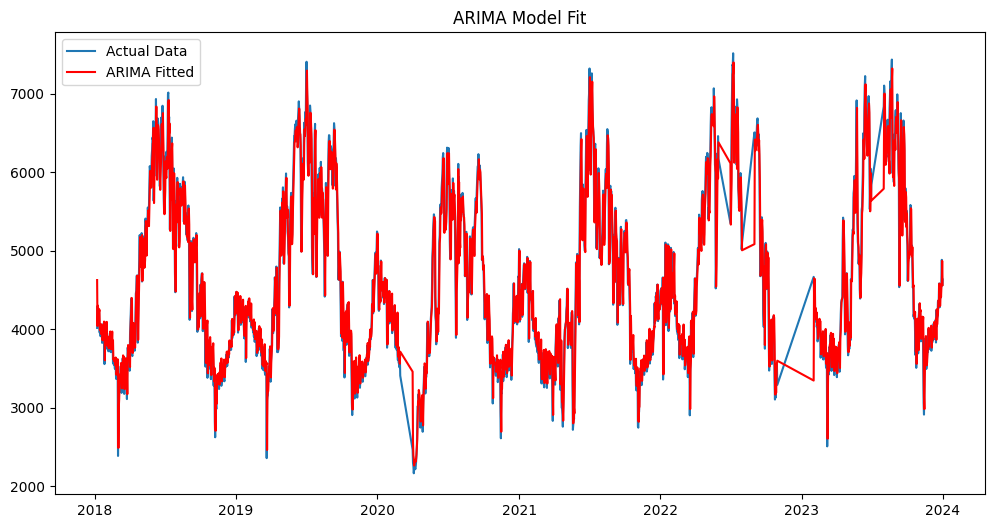

In [ ]:
# ARIMA Model
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

arima_model = ARIMA(ts, order=(1,0,1))
arima_fit = arima_model.fit()

# Get fitted values
arima_fitted = arima_fit.fittedvalues

# Plot
plt.figure(figsize=(12,6))
plt.plot(ts, label="Actual Data")
plt.plot(arima_fitted, color='red', label="ARIMA Fitted")
plt.legend()
plt.title("ARIMA Model Fit")
plt.show()

forecast future values

In [ ]:
# forecast = model_fit.forecast(steps=30)

# plt.figure(figsize=(10,5))
# plt.plot(ts, label='Actual')
# plt.plot(forecast, color='red', label='Forecast')
# plt.legend()
# plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(ts,
                       order=(1,0,1),
                       seasonal_order=(1,0,1,7))

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())
print("SARIMA AIC:", sarima_fit.aic)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                       peak_demand   No. Observations:                 1957
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -13858.199
Date:                           Wed, 04 Mar 2026   AIC                          27726.398
Time:                                   00:09:51   BIC                          27754.294
Sample:                                        0   HQIC                         27736.652
                                          - 1957                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9686      0.006    153.885      0.000       0.956       0.981
ma.L1         -0.0047      0.018     -0.269

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


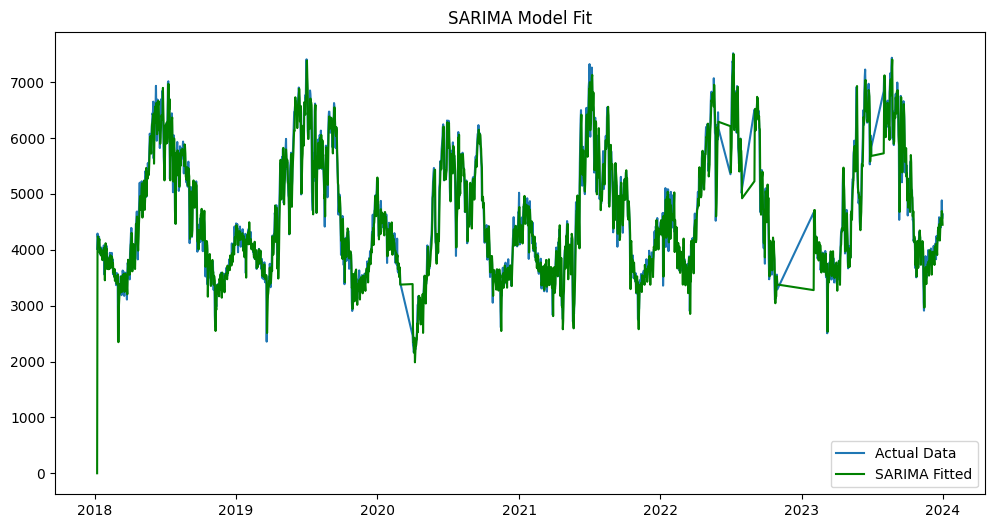

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(ts,
                       order=(1,0,1),
                       seasonal_order=(1,0,1,7))

sarima_fit = sarima_model.fit()

sarima_fitted = sarima_fit.fittedvalues

plt.figure(figsize=(12,6))
plt.plot(ts, label="Actual Data")
plt.plot(sarima_fitted, color='green', label="SARIMA Fitted")
plt.legend()
plt.title("SARIMA Model Fit")
plt.show()

In [ ]:
print("ARIMA AIC:", arima_fit.aic)
print("SARIMA AIC:", sarima_fit.aic)

ARIMA AIC: 27877.628718502776
SARIMA AIC: 27726.39773016672


In [ ]:
# train = ts[:int(len(ts)*0.8)]
# test = ts[int(len(ts)*0.8):]

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

arima_model = ARIMA(train, order=(1,0,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))

print("ARIMA RMSE:", arima_rmse)
print("ARIMA AIC:", arima_fit.aic)

ARIMA RMSE: 1125.2932498174805
ARIMA AIC: 22190.184844092604


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. f

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train,
                       order=(1,0,1),
                       seasonal_order=(1,0,1,7))

sarima_fit = sarima_model.fit()

sarima_forecast = sarima_fit.forecast(steps=len(test))

sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

print("SARIMA RMSE:", sarima_rmse)
print("SARIMA AIC:", sarima_fit.aic)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMA RMSE: 2255.726042276293
SARIMA AIC: 22033.382570063884


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pre

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "AIC": [arima_fit.aic, sarima_fit.aic],
    "RMSE": [arima_rmse, sarima_rmse]
})

print(comparison)

    Model           AIC         RMSE
0   ARIMA  27877.628719  1125.293250
1  SARIMA  22033.382570  2255.726042


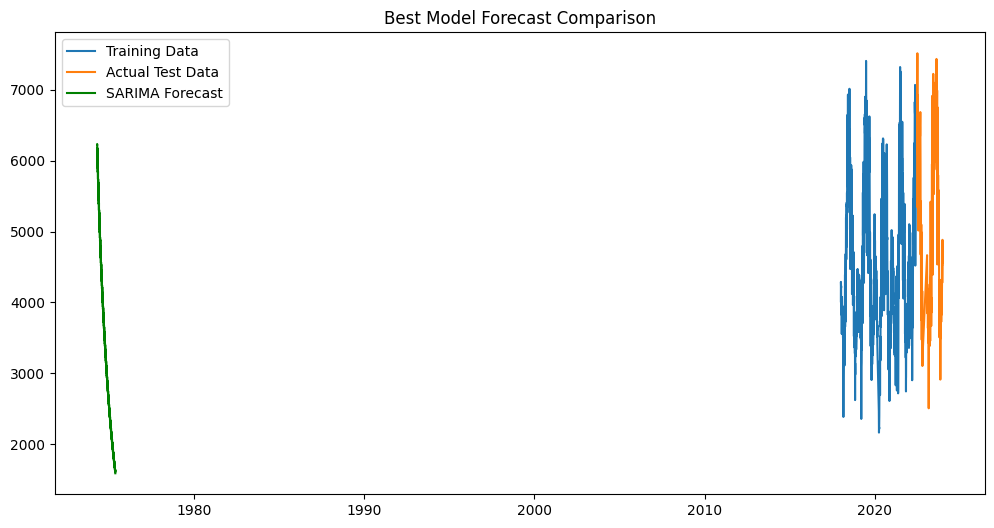

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(sarima_forecast, label="SARIMA Forecast", color='green')

plt.legend()
plt.title("Best Model Forecast Comparison")
plt.show()

In [ ]:
import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))

seasonal_pdq = [(x[0], x[1], x[2], 7) for x in pdq]

best_aic = float("inf")
best_param = None
best_seasonal = None

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            model = SARIMAX(ts,
                            order=param,
                            seasonal_order=seasonal_param,
                            enforce_stationarity=False,
                            enforce_invertibility=False)

            results = model.fit(disp=False)

            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_seasonal = seasonal_param

        except:
            continue

print("Best SARIMA Order:", best_param)
print("Best Seasonal Order:", best_seasonal)
print("Best AIC:", best_aic)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. f

Best SARIMA Order: (1, 1, 1)
Best Seasonal Order: (0, 1, 1, 7)
Best AIC: 27489.67882740819


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_model = SARIMAX(ts,
                      order=(1,0,1),
                      seasonal_order=(1,0,1,7))

final_fit = final_model.fit()

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  r

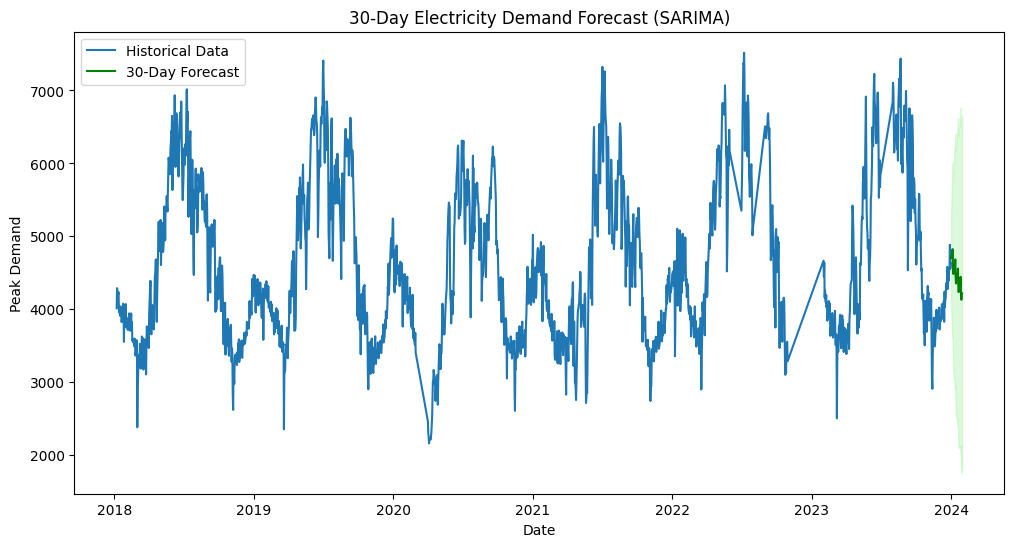

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12,6))

# plt.plot(ts[-200:], label="Historical Data")
# plt.plot(forecast_mean, label="30-Day Forecast", color='green')

# plt.fill_between(confidence_intervals.index,
#                  confidence_intervals.iloc[:, 0],
#                  confidence_intervals.iloc[:, 1],
#                  color='lightgreen', alpha=0.3)

# plt.legend()
# plt.title("30-Day Electricity Demand Forecast (SARIMA)")
# plt.xlabel("Date")
# plt.ylabel("Peak Demand")
# plt.show()
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Fit the SARIMA model on the full dataset
final_model = SARIMAX(ts,
                      order=(1,0,1),
                      seasonal_order=(1,0,1,7))
final_fit = final_model.fit()

# Forecast horizon
forecast_steps = 30  # 30 days

# Generate forecast
forecast_result = final_fit.get_forecast(steps=forecast_steps)

# Get mean forecast and confidence intervals
forecast_mean = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int()

# Create future date index
last_date = ts.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

# Assign proper index to forecast
forecast_mean.index = future_dates
confidence_intervals.index = future_dates

# Plot
plt.figure(figsize=(12,6))
plt.plot(ts, label="Historical Data")
plt.plot(forecast_mean, color='green', label="30-Day Forecast")
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:,0],
                 confidence_intervals.iloc[:,1],
                 color='lightgreen', alpha=0.3)
plt.title("30-Day Electricity Demand Forecast (SARIMA)")
plt.xlabel("Date")
plt.ylabel("Peak Demand")
plt.legend()
plt.show()

In [ ]:
print(forecast_mean)

NameError: name 'forecast_mean' is not defined

In [136]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Fit SARIMA model
final_model = SARIMAX(ts,
                      order=(1,0,1),
                      seasonal_order=(1,0,1,7))

final_fit = final_model.fit()

# Forecast horizon (5 years of daily data)
forecast_steps = 1825   # 5 years

# Generate forecast
forecast_result = final_fit.get_forecast(steps=forecast_steps)

forecast_mean = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int()

# Create future date index
last_date = ts.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=forecast_steps,
                             freq='D')

# Assign index
forecast_mean.index = future_dates
confidence_intervals.index = future_dates

# Plot
plt.figure(figsize=(12,6))

plt.plot(ts, label="Historical Data")
plt.plot(forecast_mean, label="5-Year Forecast", color='green')

plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:,0],
                 confidence_intervals.iloc[:,1],
                 color='lightgreen', alpha=0.3)

plt.title("5-Year Electricity Demand Forecast (SARIMA)")
plt.xlabel("Date")
plt.ylabel("Peak Demand")
plt.legend()
plt.show()

NameError: name 'ts' is not defined